In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder


In [28]:
df = pd.read_csv('restaurant_data.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (8368, 17)


,Name,Location,Cuisine,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Ambience Score,Service Quality Score,Parking Availability,Weekend Reservations,Weekday Reservations,Revenue
0,Restaurant 0,Rural,Japanese,4.0,38,73.98,2224,23406,13,185,161.924906,1.3,7.0,Yes,13,4,638945.52
1,Restaurant 1,Downtown,Mexican,3.2,76,28.11,4416,42741,8,533,148.759717,2.6,3.4,Yes,48,6,490207.83
2,Restaurant 2,Rural,Italian,4.7,48,48.29,2796,37285,18,853,56.849189,5.3,6.7,No,27,14,541368.62
3,Restaurant 3,Rural,Italian,4.4,34,51.55,1167,15214,13,82,205.433265,4.6,2.8,Yes,9,17,404556.80
4,Restaurant 4,Downtown,Japanese,4.9,88,75.98,3639,40171,9,78,241.681584,8.6,2.1,No,37,26,1491046.35
5,Restaurant 5,Downtown,Indian,4.4,79,35.69,6787,75378,5,400,247.544461,2.0,8.5,Yes,27,22,644220.90
6,Restaurant 6,Rural,Mexican,4.9,49,35.30,2594,32587,11,106,206.159035,1.5,5.3,No,12,28,400348.65
7,Restaurant 7,Suburban,Japanese,4.1,61,73.65,3213,33429,14,377,135.319312,1.8,4.6,No,56,23,1014153.65
8,Restaurant 8,Rural,Japanese,4.2,37,73.75,3437,37102,18,494,55.652417,7.1,9.4,Yes,27,24,635606.10
9,Restaurant 9,Rural,French,5.0,32,59.80,2569,28419,18,907,273.944887,6.4,7.4,No,12,19,452920.65


In [29]:
df.isna().sum()

Name                      0
Location                  0
Cuisine                   0
Rating                    0
Seating Capacity          0
Average Meal Price        0
Marketing Budget          0
Social Media Followers    0
Chef Experience Years     0
Number of Reviews         0
Avg Review Length         0
Ambience Score            0
Service Quality Score     0
Parking Availability      0
Weekend Reservations      0
Weekday Reservations      0
Revenue                   0
dtype: int64

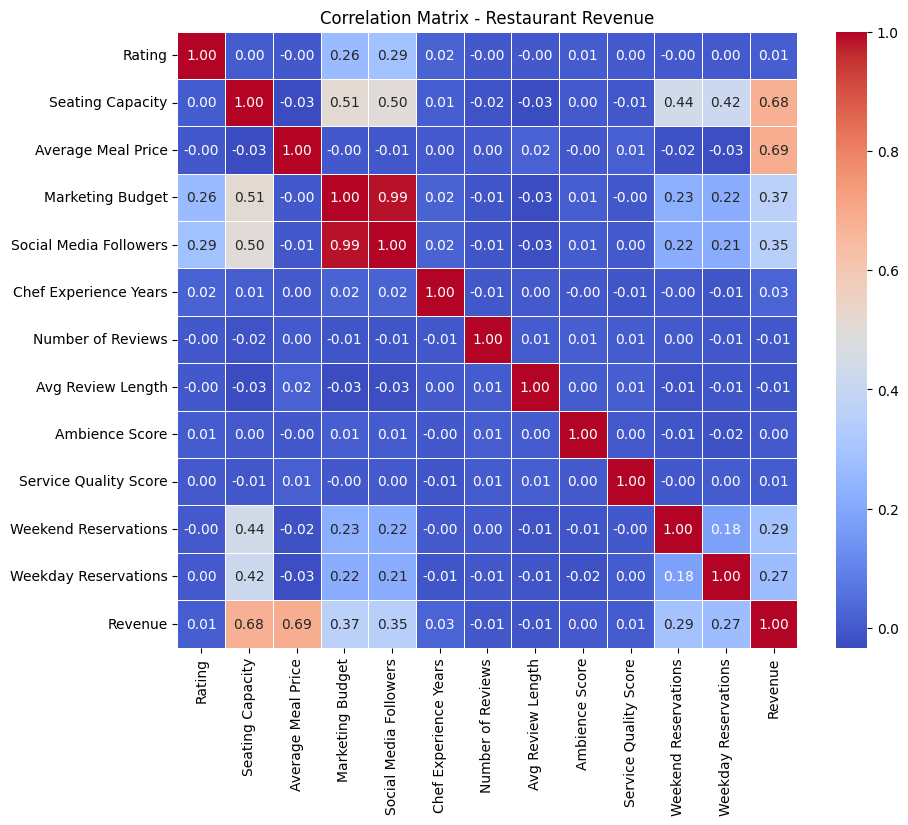

In [30]:
cols = [
    'Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget',
    'Social Media Followers', 'Chef Experience Years', 'Number of Reviews',
    'Avg Review Length', 'Ambience Score', 'Service Quality Score',
    'Weekend Reservations', 'Weekday Reservations', 'Revenue'
]

matrix_corr = df[cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix - Restaurant Revenue")
plt.show()

In [ ]:
feature_cols = [
    'Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget',
    'Social Media Followers', 'Chef Experience Years', 'Number of Reviews',
    'Avg Review Length', 'Ambience Score', 'Service Quality Score',
    'Weekend Reservations', 'Weekday Reservations'
]

X = df[feature_cols]
y = df['Revenue']

In [32]:
df[feature_cols].describe()

,Rating,Seating Capacity,Average Meal Price,Marketing Budget,Social Media Followers,Chef Experience Years,Number of Reviews,Avg Review Length,Service Quality Score,Weekend Reservations,Weekday Reservations
count,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000,8368.000000
mean,4.008258,60.212835,47.896659,3218.254900,36190.621773,10.051984,523.010397,174.769974,5.508772,29.491754,29.235301
std,0.581474,17.399488,14.336767,1824.896053,18630.153330,5.516606,277.215127,71.998060,2.586552,20.025415,20.004277
min,3.000000,30.000000,25.000000,604.000000,5277.000000,1.000000,50.000000,50.011717,1.000000,0.000000,0.000000
25%,3.500000,45.000000,35.490000,1889.000000,22592.500000,5.000000,277.000000,113.311102,3.200000,13.000000,13.000000
50%,4.000000,60.000000,45.535000,2846.500000,32518.500000,10.000000,528.000000,173.910079,5.600000,27.000000,26.000000
75%,4.500000,75.000000,60.300000,4008.500000,44566.250000,15.000000,764.250000,237.406885,7.800000,43.000000,43.000000
max,5.000000,90.000000,76.000000,9978.000000,103777.000000,19.000000,999.000000,299.984924,10.000000,88.000000,88.000000


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )


In [34]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [35]:
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("\n=== MODEL PERFORMANCE ===")
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"MAE      : {mae:,.2f}")

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"CV R² Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


=== MODEL PERFORMANCE ===
R² Score : 0.9555
RMSE     : 56,453.71
MAE      : 43,184.53
CV R² Mean: 0.9578 ± 0.0006
